<a href="https://colab.research.google.com/github/GildasTaliah/ML-In-Finance/blob/main/ReinforcementLearning%2BPy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **REINFORCEMENT LEARNING WITH GYMNASIUM IN PYTHON**


**Description**

Embark on an exhilarating exploration of Reinforcement Learning (RL), a pivotal branch of machine learning. This interactive course takes you on a comprehensive journey through the core principles of RL where you'll master the art of training intelligent agents, teaching them to make strategic decisions and maximize rewards. Your agents will learn to navigate a whole host of different environments from OpenAI's gym toolkit, including navigating frozen lakes and mountains.

# **1 Introduction to Reinforcemennt Learning**


Dive into the exciting world of Reinforcement Learning (RL) by exploring its foundational concepts, roles, and applications. Navigate through the RL framework, uncovering the agent-environment interaction. You'll also learn how to use the Gymnasium library to create environments, visualize states, and perform actions, thus gaining a practical foundation in RL concepts and applications.

**What is Reinforcement Learning?**

In the field of machine learning, reinforcement learning (RL) is a unique approach where models learn to make decisions. It finds extensive applications in various domains.

Which of the following statements is correct about RL?

- RL is based on rewarding desirable behaviors or punishing undesirable ones - T
- RL is primarily used for classificationtask in Machine Learning. - F
- RL can only be used to develop self-learning - F
- RL is based on the interaction between an agent and an environment to achieve a specific goal - T


Excellent work! You've successfully identified the key aspects of reinforcement learning. Keep up the great learning!

**RL vs. other ML sub-domains**

In machine learning, understanding the differences between supervised, unsupervised, and reinforcement learning is crucial not only for grasping their unique characteristics but also for determining the most appropriate application for each. This knowledge guides decision-making in selecting the right approach for specific problems, ensuring more effective and efficient solutions.

- **Supervised Learning:**
-- Learne to predict outcome based on labelled data
-- Used to perform classification task.

- **Unsupervised Learning:**
-- Finds patterns and relationship in unlabelled data.
-- Used to perfrom clustering.

- **Reinforcement Learning:**
-- Uses rewards and punishment to Guide learning.
-- Learns to make decision thruogh trial and errors.

Fantastic! You've successfully differentiated between RL and the other ML types. Grasping these distinctions is essential for recognizing the optimal scenarios for applying each sub-domain, ensuring the most effective use of machine learning to achieve your goals.

**Scenarios for applying RL**

Although RL is a powerful tool, it's not always the necessary approach. Now, you'll evaluate various practical scenarios to determine whether they are suited for RL or not.


- **Appropriate for RL**
-- Buidling a spam detection system that continuosly adapts its filtering criteria based on user interactions like marking emails as spam or not spam.
-- Buidling a recommendation system that adjusts its suggestions based on user interactions and feedback, such as watch time and user rating.
-- Developing a self-driving car that learns optimal driving strategies through simulations receiving feedback based on safety and efficiency metrics.





- **Not Appropriate for RL**
-- Buidling a spam filter for and email client that classifies emails as spam or not spam, based on pre-labelled data set of emails categorized by users (Sup-Class)
-- Training a self driving car algorithm using a data set of road images and corresponding driving actions to accurately predict steering angles.
-- Building a movie recommendation system using a data set of user ratings for movies to predict user preference.

Bravo! You've adeptly identified which scenarios are suitable for RL and which are not. This demonstrates that you are now well-equipped with a solid understanding of RL fundamentals and are ready to dive deeper. Let's get to it!

**RL interaction loop**

As you know by now, RL involves an agent making decisions in an environment to maximize some notion of cumulative reward. The agent must discover which actions yield the most reward through interaction.




In [ ]:
import gymnasium as gym

# import necessary package


#env = create_environment()
#state = env.get_initial_state()

#n_iterations = 10

#for i in range(n_iterations):
 # action = choose_action(state)
  #state, reward = env.execute_action(action)
  #update_knowledge(state, action, reward)




"""
Great work! You've successfully implemented the generic RL loop, which is the core of \
the RL framework. This loop enables the agent to iteratively interact with the environment,\
 thereby enhancing its decision-making capabilities.
"""

"\nGreat work! You've successfully implemented the generic RL loop, which is the core of the RL framework. This loop enables the agent to iteratively interact with the environment, thereby enhancing its decision-making capabilities.\n"

In [ ]:
# Code adapted from claude to illustrate example better

import gymnasium as gym
import numpy as np
import random

class SimpleAgent:
    def __init__(self, action_space):
        self.action_space = action_space
        self.q_table = {}
        self.learning_rate = 0.1
        self.gamma = 0.95
        self.epsilon = 0.1

    def discretize_state(self, state):
        # Round state values to reduce state space
        return tuple(np.round(state, decimals=1))

    def get_action(self, state):
        state = self.discretize_state(state)

        # Epsilon-greedy action selection
        if random.random() < self.epsilon:
            return self.action_space.sample()

        # Get all Q-values for this state
        q_values = [self.q_table.get((state, action), 0.0)
                   for action in range(self.action_space.n)]
        return np.argmax(q_values)

    def learn(self, state, action, reward, next_state):
        state = self.discretize_state(state)
        next_state = self.discretize_state(next_state)

        # Get current Q-value
        current_q = self.q_table.get((state, action), 0.0)

        # Get max Q-value for next state
        next_q_values = [self.q_table.get((next_state, a), 0.0)
                        for a in range(self.action_space.n)]
        max_next_q = max(next_q_values)

        # Q-learning update
        new_q = current_q + self.learning_rate * (
            reward + self.gamma * max_next_q - current_q)

        # Update Q-table
        self.q_table[(state, action)] = new_q

def train():
    # Create environment
    env = gym.make('CartPole-v1')

    # Create agent
    agent = SimpleAgent(env.action_space)

    # Training parameters
    episodes = 100
    max_steps = 500

    # Training loop
    for episode in range(episodes):
        state, _ = env.reset()
        episode_reward = 0

        for step in range(max_steps):
            # Get action
            action = agent.get_action(state)

            # Execute action
            next_state, reward, terminated, truncated, _ = env.step(action)

            # Learn from experience
            agent.learn(state, action, reward, next_state)

            episode_reward += reward
            state = next_state

            if terminated or truncated:
                break

        # Print progress every 10 episodes
        if (episode + 1) % 10 == 0:
            print(f"Episode {episode + 1}, Reward: {episode_reward}")

    env.close()
    return agent

# Run training
if __name__ == "__main__":
    trained_agent = train()

Episode 10, Reward: 9.0
Episode 20, Reward: 14.0
Episode 30, Reward: 9.0
Episode 40, Reward: 10.0
Episode 50, Reward: 10.0
Episode 60, Reward: 12.0
Episode 70, Reward: 12.0
Episode 80, Reward: 10.0
Episode 90, Reward: 11.0
Episode 100, Reward: 9.0


**Episodic and continuous RL tasks***

In RL, tasks can be categorized into two main types: **episodic and continuous**. Understanding the difference between these two types is crucial for designing appropriate RL algorithms.

**Episodic and continuous RL tasks**

In RL, tasks can be categorized into two main types: episodic and continuous. Understanding the difference between these two types is crucial for designing appropriate RL algorithms.

- **Episodic**
-- Playing a footbal match.
-- Playing a game of chess.
-- Solving a complex puzzle.

$\,$

- **Continuos**
-- Optimizing smart grid energy consumption
-- Modulating traffic signal timings based on real-time flow
-- Monitoring stock market data to make buy or sell decisions.



Fantastic work! You've successfully grasped the critical difference between episodic and continuous tasks, a cornerstone in tailoring Reinforcement Learning strategies to diverse real-life applications.

**Calculating discounted returns for agent strategies**

Discounted returns help in evaluating the total amount of rewards an agent can expect to accumulate over time, taking into account that future rewards are less valuable than immediate rewards. You are given the expected rewards for two different strategies (exp_rewards_strategy_1 and exp_rewards_strategy_2) of an RL agent. Your task is to calculate the discounted return for each strategy and determine which one yields the higher return.

The numpy library has been imported for you as np.

In [ ]:
exp_rewards_strategy_1 = np.array([3, 2, -1, 5])

discount_factor = 0.9

# Compute discounts
discounts_strategy_1 = np.array( [ discount_factor **i for i in range(len(exp_rewards_strategy_1))])

# Compute the discounted return
discounted_return_strategy_1 = np.sum(exp_rewards_strategy_1 * discounts_strategy_1)

print(f"The discounted return of the first strategy is {discounted_return_strategy_1}")



###

exp_rewards_strategy_2 = np.array([6, -5, -3, -2])

discount_factor = 0.9

# Compute discounts
discounts_strategy_2 = np.array( [ discount_factor **i for i in range(len(exp_rewards_strategy_2))])

# Compute the discounted return
discounted_return_strategy_2 = np.sum(exp_rewards_strategy_2 * discounts_strategy_2)

print(f"The discounted return of the second strategy is {discounted_return_strategy_2}")



"""
Excellent! You've now mastered calculating discounted returns for agent strategies. \
These returns help the agent compare various strategies effectively, guiding it in selecting the most advantageous path.

"""


The discounted return of the first strategy is 7.635
The discounted return of the second strategy is -2.3880000000000003


"\nExcellent! You've now mastered calculating discounted returns for agent strategies. These returns help the agent compare various strategies effectively, guiding it in selecting the most advantageous path.\n\n"

In [ ]:
import gymnasium as gym


env = gym.make('CartPole-v1', render_mode = 'rgb_array')
state, info = env.reset(seed = 1)
print(state)

[ 0.00118216  0.04504637 -0.03558404  0.04486495]


**Setting up a Mountain Car environment**

One of the most common Gym environments is Mountain Car, where the goal is to drive an underpowered car up a steep hill. The car's engine isn't strong enough to climb the hill in a single pass, so the car needs to build up momentum by driving back and forth. Your task is to create and set up this environment.

In [ ]:
# Import the gymnaisum library
import gymnasium as gym

# Create the environment
#env = gym.make('MountainCar', render_mode='rgb_array')
env = gym.make('MountainCar-v0', render_mode='rgb_array')

# Get the initial state
initial_state, info = env.reset(seed=42)

position = initial_state[0]
velocity = initial_state[1]

print(f"The position of the car along the x-axis is {position} (m)")
print(f"The velocity of the car is {velocity} (m/s)")

"Bravo! You've masterfully initialized the Mountain Car environment using Gymnasium. \
This achievement lays the groundwork for deeper exploration and innovation within RL\
 frameworks. Continue on this path of discovery and development!"

The position of the car along the x-axis is -0.4452087879180908 (m)
The velocity of the car is 0.0 (m/s)


"Bravo! You've masterfully initialized the Mountain Car environment using Gymnasium. This achievement lays the groundwork for deeper exploration and innovation within RL frameworks. Continue on this path of discovery and development!"

**Visualizing the Mountain Car Environment**

Now, you'll take a step further in your exploration of the Mountain Car environment. Visualization is a key aspect of understanding the dynamics of RL environments. You'll write a function render() that displays the current state of the environment. This function will be used later on for any environment you want to visualize.

matplotlib.pyplot and gymnasium have been imported as plt and gym.

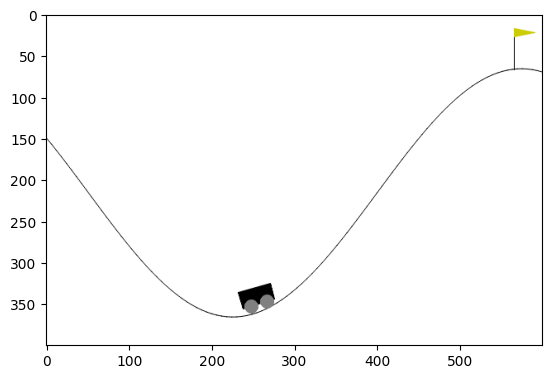

"Fantastic! You've successfully visualized the Mountain Car environment. The function you created will be incredibly helpful for you in future exercises."

In [ ]:
import matplotlib.pyplot as plt
import gymnasium as gym

env = gym.make('MountainCar-v0', render_mode='rgb_array')
initial_state, _ = env.reset()

# Complete the render function
def render():
    state_image = env.render()
    plt.imshow(state_image)
    plt.show()

# Call the render function
render()

"Fantastic! You've successfully visualized the Mountain Car environment. The function you created will be incredibly helpful for you in future exercises."

**Interacting with the Frozen Lake environment**


Now you'll navigate the Frozen Lake environment, a grid-based world where actions move an agent in specific directions. Your task is to carefully look at the environment, and manually define a list of actions that will navigate the agent from the start (top left) to the goal (bottom right) without falling into any holes. In the Frozen Lake environment, actions are typically represented as:

**0: left**

**1: down**

**2: right**

**3: up**

After running your code, be sure to navigate through your plots to see the path taken by using the 'Previous Plot' and 'Next Plot' buttons. This will help you understand the sequence of actions and their outcomes.

gym and plt have been imported along with the render() function and the env variable.

In [ ]:
env = gym.make('FrozenLake-v1', render_mode='rgb_array')
initial_state, _ = env.reset()

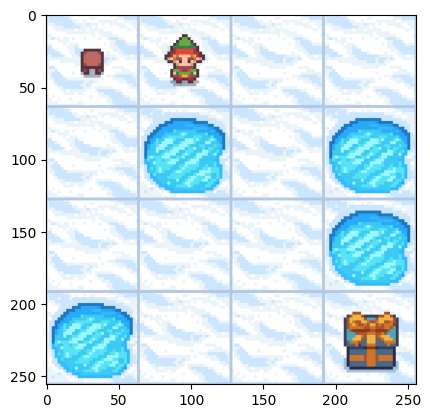

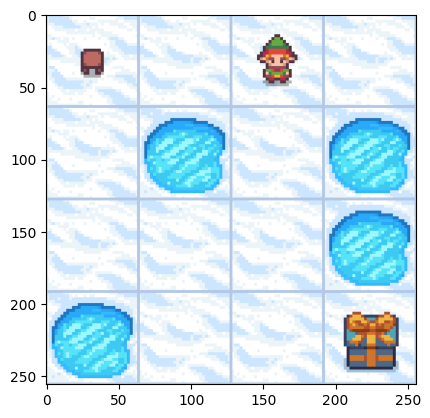

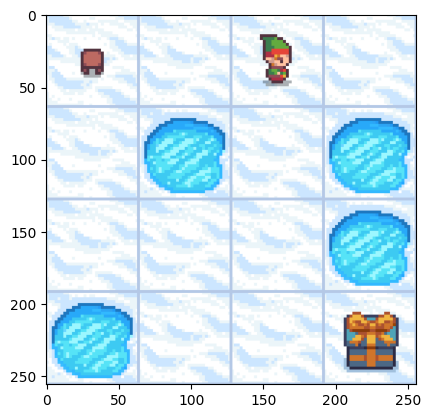

"Great job! Just like you manually found a path in Frozen Lake, RL algorithms learn to do this through trial and error. What you've accomplished manually is a sneak peek into the exciting world of RL you'll explore in the upcoming chapters. Get ready to dive deeper!"

In [ ]:
# Define the sequence of actions
actions = [1, 1, 2]# 2, 1, 2]

for action in actions:
  # Execute each action
  state, reward, terminated, _, _ = env.step(action)
  # Render the environment
  render()
  if terminated:
  	print("You reached the goal!")

"Great job! Just like you manually found a path in Frozen Lake, RL algorithms \
learn to do this through trial and error. What you've accomplished manually is a \
sneak peek into the exciting world of RL you'll explore in the upcoming chapters. \
Get ready to dive deeper!"

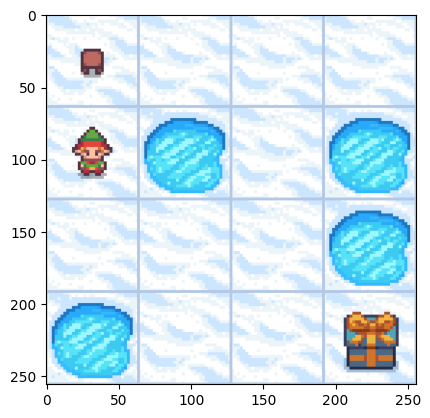

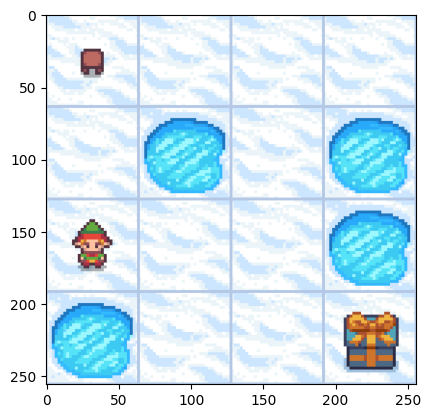

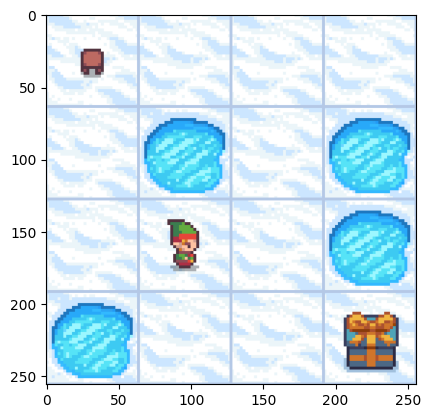

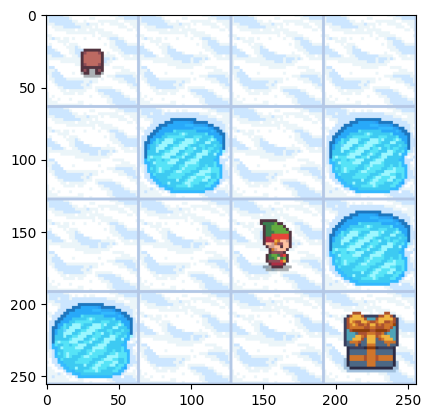

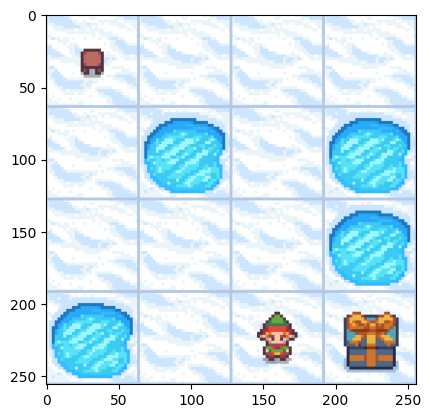

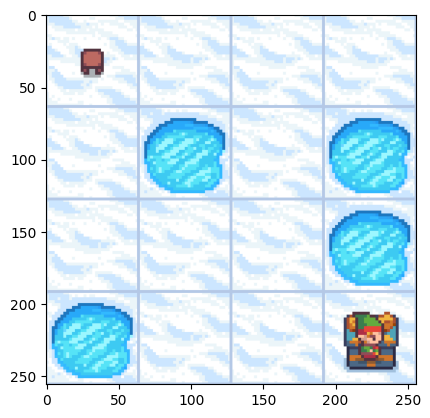

You reached the goal!


"Great job! Just like you manually found a path in Frozen Lake, RL algorithms learn to do this through trial and error. What you've accomplished manually is a sneak peek into the exciting world of RL you'll explore in the upcoming chapters. Get ready to dive deeper!"

In [ ]:
# is_slippery == False to make actions deterministic
env = gym.make('FrozenLake-v1', is_slippery = False, render_mode='rgb_array')
initial_state, _ = env.reset()

# Define the sequence of actions
actions = [1, 1, 2, 2, 1, 2]

for action in actions:
  # Execute each action
  state, reward, terminated, _, _ = env.step(action)
  # Render the environment
  render()
  if terminated:
  	print("You reached the goal!")



"Great job! Just like you manually found a path in Frozen Lake, RL algorithms learn to do this through trial and error. What you've accomplished manually is a sneak peek into the exciting world of RL you'll explore in the upcoming chapters. Get ready to dive deeper!"

**Recap**

When you left 21 hours ago, you worked on Model-Based Learning, chapter 2 of the course Reinforcement Learning with Gymnasium in Python. Here is what you covered in your last lesson:

You learned about the foundational concepts of Reinforcement Learning (RL) and how to practically apply them using the Gymnasium library in Python. Here's a summary of the key points:

- Gymnasium Library: A toolkit for developing and comparing RL algorithms with a variety of environments, from simple control tasks to complex games.
Creating Environments: You used **gym.make()** to create environments like CartPole and MountainCar, specifying render_mode='rgb_array' for visualizing states.
- Initializing Environments: The **env.reset()** method initializes the environment and returns the initial state and auxiliary information.
Visualizing States: You created a **render()** function to visualize the environment using Matplotlib:

# **2. Model Based Learning**

Delve deeper into the world of RL focusing on model-based learning. Unravel the complexities of Markov Decision Processes (MDPs), understanding their essential components. Enhance your skill set by learning about policies and value functions. Gain expertise in policy optimization with policy iteration and value Iteration techniques.

**Custom Frozen Lake MDP components**

The provided grid world environment is a variation of the Frozen Lake environment where an agent must navigate to a goal while avoiding holes. Your task is to analyze this environment and frame it as an MDP by answering specific questions.

You may attempt to answer by visually inspecting the environment, where applicable, or by utilizing the env variable pre-loaded for you.
There are 5 holes and a reward.


A frozen lake with rectangle sides 3X6.  

- Question

How Many Actions Do We Have?
- 4: 0, 1, 2, & 3.
- Question

How many states do we have?
- 18: 3*6.

- Question

How many terminal states do we have?
- 5 holes and a reward: 6.

In deterministic environments, each action leads to a specific outcome, whereas in stochastic environments, an action may lead to several outcomes.

- Question
In deterministic environments, each action leads to a specific outcome, whereas in stochastic environments, an action may lead to several outcomes.

Is the environment deterministic or stochastic?
- Stochastic.


Congratulations! You've skillfully pinpointed the key MDP components within this environment. Your proficiency in identifying these elements is a significant step towards mastering RL strategies and applying them adeptly to solve complex problems. Keep up the great work!






**Exploring state and action spaces**

The Cliff Walking environment involves an agent crossing a grid world from start to goal while avoiding falling off a cliff. If the player moves to a cliff location it returns to the start location. The player makes moves until they reach the goal, which ends the episode. Your task is to explore the state and action spaces of this environment.

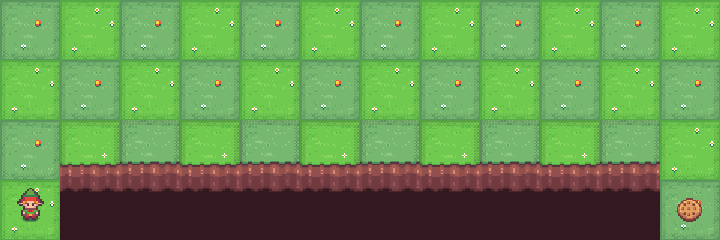

In [ ]:
# Create the Cliff Walking environment
env = gym.make('CliffWalking-v0')

# Compute the size of the action space
num_actions = env.action_space.n

# Compute the size of the state space
num_states = env.observation_space.n

print("Number of actions:", num_actions)
print("Number of states:", num_states)

"Fantastic job! You've accurately determined the action and state spaces in the \
Cliff Walking environment. This understanding is key to designing strategies that \
navigate through environments effectively, optimizing decision-making processes in RL tasks."

Number of actions: 4
Number of states: 48


"Fantastic job! You've accurately determined the action and state spaces in the Cliff Walking environment. This understanding is key to designing strategies that navigate through environments effectively, optimizing decision-making processes in RL tasks."

**Transition probabilities and rewards**

The Cliff Walking environment has 48 states, numbered from 0 to 47, line by line, from the upper left corner (0) to the lower right corner (47). Your goal is to investigate the structure of transition probabilities and rewards within this setup. Notably, all rewards, including the reward for reaching the goal, are negative in this environment. This design choice emphasizes minimizing the number of steps taken, as each step incurs a penalty, making efficiency a key aspect for designing effective learning algorithms.

The gymnasium library has been imported as gym and the environment as env. Also num_states and num_actions from the previous exercise have been imported.

In [ ]:
# Choose the state
state = 35

# Extract transitions for each state-action pair
for action in range(num_actions):
    transitions = env.unwrapped.P[state][action]
    # Print details of each transition
    for transition in transitions:
        probability, next_state, reward, done = transition
        print(f"Probability: {probability}, Next State: {next_state}, Reward: {reward}, Done: {done}")

Probability: 1.0, Next State: 23, Reward: -1, Done: False
Probability: 1.0, Next State: 35, Reward: -1, Done: False
Probability: 1.0, Next State: 47, Reward: -1, Done: True
Probability: 1.0, Next State: 34, Reward: -1, Done: False


- Question

Is this environment deterministic or stochastic?
- DEterministic


Outstanding work! You've adeptly deciphered the structure of the Cliff Walking environment, identifying whether it operates on deterministic or stochastic principles. Recognizing the nature of transition probabilities is essential for designing robust RL algorithms tailored to the environment's dynamics.

**Defining a deterministic policy**

In this exercise, you'll be working with a custom environment called MyGridWorld, the same one you've seen in the video. This environment is a grid world where the agent's goal is to reach the diamond as quickly as possible. Your task is to define a policy that guides the agent's behavior as specified in the figure below.




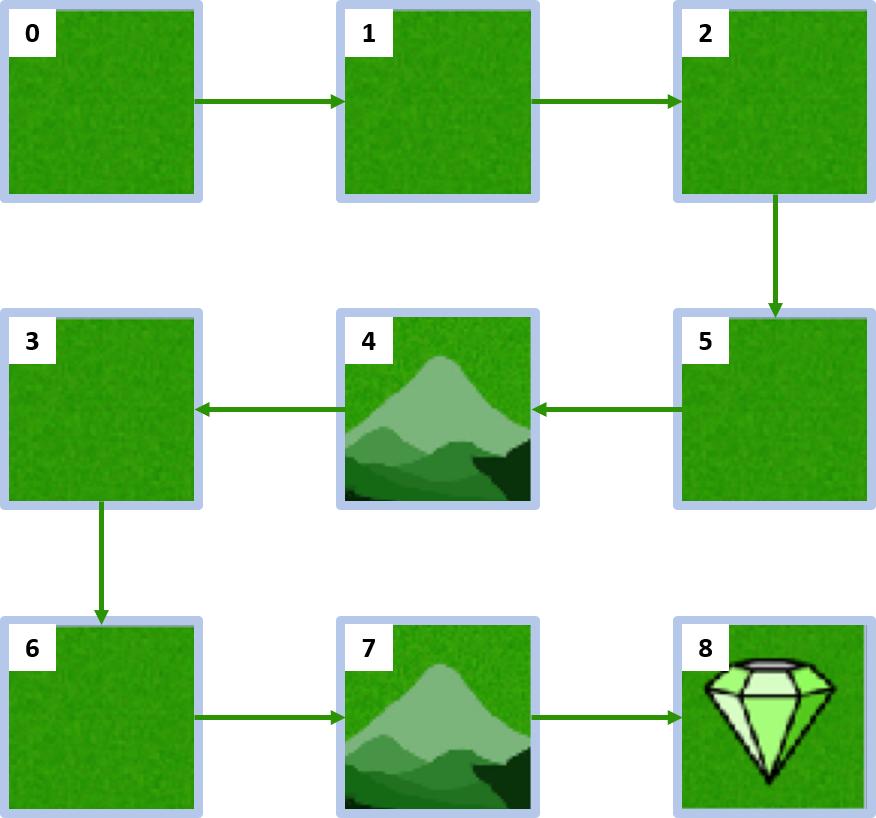









Actions are represented as: (0 → left, 1 → down, 2 → right, 3 → up).

The gymnasium library has been imported for you as gym along with the render() function.

In [ ]:
# Complete the render function
#def render():
 #   state_image = env.render()
 #   plt.imshow(state_image)
  #  plt.show()

# Call the render function
#render()

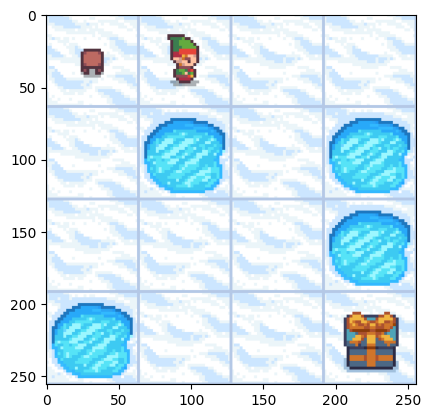

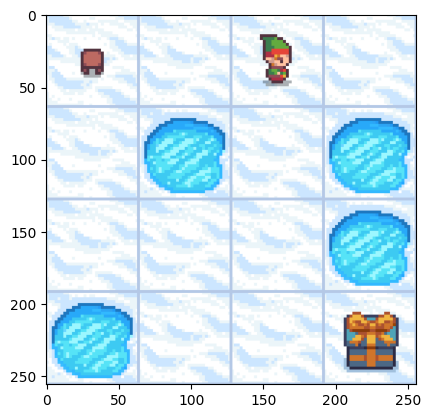

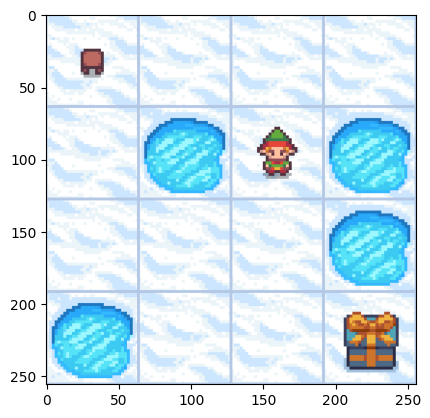

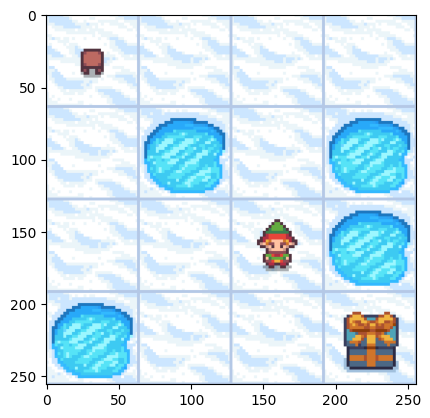

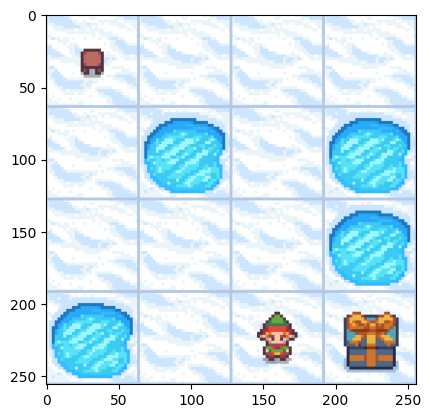

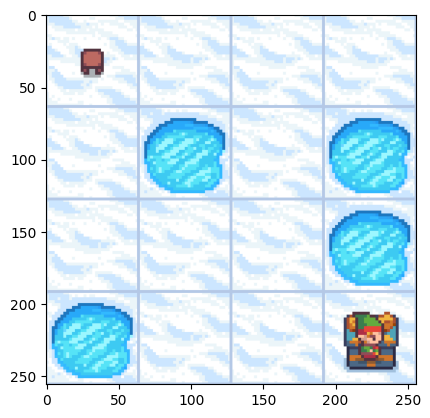

In [ ]:
# Create the environment
#env = gym.make('MyGridWorld-v1', render_mode='rgb_array')
env = gym.make('FrozenLake-v1', render_mode='rgb_array', is_slippery = False)
state, info = env.reset()

# Define the policy
policy = {0:2, 1:2, 2:1, 3:0, 4:1, 5:2, 6:1, 7:0, 8:2, 9:2, 10:1, 14:2}

terminated = False
while not terminated:
  # Select action based on policy
  action = policy[state]
  state, reward, terminated, truncated, info = env.step(action)
  # Render the environment
  render()

  "Bravo! You've observed the agent's behavior under the defined policy, gaining insight into how policies guide actions in a grid world environment!"

**Computing state-values for a policy**

Using the same deterministic environment MyGridWorld, now you need to evaluate the effectiveness of the policy you defined in the previous exercise. You'll do this by computing the state value function for each state under this policy.

The environment has been imported as env along with the necessary variables needed (terminal_state, num_states, policy, gamma).

In [ ]:
print(f'Current policy {policy}')

Current policy {0: 2, 1: 2, 2: 1, 3: 0, 4: 1, 5: 2, 6: 1, 7: 0, 8: 2, 9: 2, 10: 1, 14: 2}


In [ ]:
def compute_state_value(state, visited=None, policy = policy):
    if visited is None:
        visited = set()

    if state == terminal_state or state in visited:
        return 0

    visited.add(state)

    if state not in policy:
        return 0

    action = policy[state]
    _, next_state, reward, _ = env.unwrapped.P[state][action][0]
    return reward + gamma * compute_state_value(next_state, visited)

# Get number of states from environment
num_states = env.observation_space.n
terminal_state = 15  # Goal state for FrozenLake
gamma = 1  # Discount factor

# Compute values for all states
state_values = {state: compute_state_value(state) for state in range(num_states)}
print(state_values)

" Excellent! You've computed and displayed the state value function, effectively evaluating the given policy in MyGridWorld! Next, you'll compare it with another policy. "

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 0, 6: 1.0, 7: 0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 0, 12: 0, 13: 0, 14: 1.0, 15: 0}


" Excellent! You've computed and displayed the state value function, effectively evaluating the given policy in MyGridWorld! Next, you'll compare it with another policy. "

In [ ]:
terminal_state, number_state, gamma = 8, 9,  1.0

#policy = {0: 2, 1: 2, 2: 1, 3: 1, 4: 0, 5: 0, 6: 2, 7: 2}
policy =  {0:2, 1:2, 2:1, 3:0, 4:1, 5:2, 6:1, 7:0, 8:2, 9:2, 10:1, 14:2}



# Complete the function
#def compute_state_value(state):
 #   if state == terminal_state:
  #      return 0
   # action = policy[state]
    #_, next_state, reward, _ = env.unwrapped.P[state][action][0]
   # return reward + gamma * compute_state_value(next_state)

# Compute all state values
#state_values = {state: compute_state_value(state) for state in range(num_states)}

#print(state_values)

#"Excellent! You've computed and displayed the state value function, effectively evaluating the given policy in MyGridWorld! Next, you'll compare it with another policy."


**Comparing policies**

You are given two state value functions (value_function_1 and value_function_2) corresponding to two different policies in the MyGridWorld environment. Your task is to compare these state value functions on a state-by-state basis to determine which policy is more effective.

The variable num_states is available for you to use.

In [ ]:
value_function_1 = {0: 1, 1: 2, 2: 3, 3: 7, 4: 6, 5: 4, 6: 8, 7: 10, 8: 0}
value_function_2 = {0: 7, 1: 8, 2: 9, 3: 7, 4: 9, 5: 10, 6: 8, 7: 10, 8: 0}

num_states = len(value_function_1)  # Corrected

# Check for each value in policy 1 if it is better than policy 2
one_is_better = [value_function_1[state] >= value_function_2[state] for state in value_function_1.keys()]

# Check for each value in policy 2 if it is better than policy 1
two_is_better = [value_function_2[state] >= value_function_1[state] for state in value_function_2.keys()]

if all(one_is_better):
    print("Policy 1 is better.")
elif all(two_is_better):
    print("Policy 2 is better.")
else:
    print("Neither policy is uniformly better across all states.")

"Great job! Now you're fully equiped to effectively analyze state-value functions and compare policies. Next, you'll dive into improving policies!"

Policy 2 is better.


"Great job! Now you're fully equiped to effectively analyze state-value functions and compare policies. Next, you'll dive into improving policies!"

**Computing Q-values**

Your goal is to compute the action-values, also known as Q-values, for each state-action pair in the custom MyGridWorld\FrozenLake environment when following the below policy. In RL, Q-values are essential because they represent the expected utility of executing a specific action in a given state, followed by adherence to the policy.







The environment has been imported as env along with the compute_state_value() function and the necessary variables needed (terminal_state, num_states, num_actions, policy, gamma).



In [ ]:
# Complete the function to compute the action-value for a state-action pair
def compute_q_value(state, action):
    if state == terminal_state:
        return None
    probability, next_state, reward, done = env.unwrapped.P[state][action][0]
    return reward + gamma * compute_state_value(next_state)

# Compute Q-values for each state-action pair
Q = {(state, action): compute_q_value(state, action) for state in range(num_states) for action in range(num_actions)}

print(Q)


"Amazing! You've successfully computed the Q-values for each state-action pair in MyGridWorld. \
Understanding these values is key to determining the best actions to take in each state."

{(0, 0): 1.0, (0, 1): 0.0, (0, 2): 1.0, (0, 3): 1.0, (1, 0): 1.0, (1, 1): 0.0, (1, 2): 1.0, (1, 3): 1.0, (2, 0): 1.0, (2, 1): 1.0, (2, 2): 1.0, (2, 3): 1.0, (3, 0): 1.0, (3, 1): 0.0, (3, 2): 1.0, (3, 3): 1.0, (4, 0): 0.0, (4, 1): 0.0, (4, 2): 0.0, (4, 3): 1.0, (5, 0): 0.0, (5, 1): 0.0, (5, 2): 0.0, (5, 3): 0.0, (6, 0): 0.0, (6, 1): 1.0, (6, 2): 0.0, (6, 3): 1.0, (7, 0): 0.0, (7, 1): 0.0, (7, 2): 0.0, (7, 3): 0.0, (8, 0): None, (8, 1): None, (8, 2): None, (8, 3): None}


"Amazing! You've successfully computed the Q-values for each state-action pair in MyGridWorld. Understanding these values is key to determining the best actions to take in each state."

**Improving a policy**

In the previous exercise, you computed the Q-values for each state-action pair in the FRozenLake/ MyGridWorld environment. Now, you'll use these Q-values to improve the existing policy. Policy improvement is a critical step in reinforcement learning, where you enhance the policy by choosing actions that maximize the expected utility (Q-value) in each state. After improving the policy, you will render the new movements according to this improved policy.

The environment has been imported as env, along with the Q-values as Q, and the render() function.

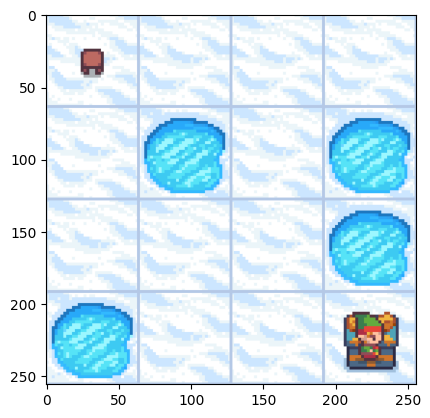

In [ ]:

# Complete the render function
def render():
    state_image = env.render()
    plt.imshow(state_image)
    plt.show()

render()

**Recap:**

Your recent learnings
When you left 6 days ago, you worked on Model-Based Learning, chapter 2 of the course Reinforcement Learning with Gymnasium in Python. Here is what you covered in your last lesson:

You learned about policies and state-value functions in the context of Reinforcement Learning (RL) using Markov Decision Processes (MDPs). Here's a summary of the key points:

Policies: These are strategies that guide the agent's actions in each state to maximize the return. For example, in a grid-world environment, a policy could dictate moving right in state 0 and down in state 1.

State-Value Functions: These functions evaluate the worth of a state by calculating the expected return starting from that state and following a given policy. The return is the sum of discounted rewards over time.

Bellman Equation: This recursive formula computes state values by combining the immediate reward of the current state with the discounted value of the next state.

Key Code Snippet:
To compute state values, you implemented the compute_state_value() function:






```
def compute_state_value(state, visited=None):
    if visited is None:
        visited = set()

    if state == terminal_state or state in visited:
        return 0

    visited.add(state)

    if state not in policy:
        return 0

    action = policy[state]
    _, next_state, reward, _ = env.unwrapped.P[state][action][0]
    return reward + gamma * compute_state_value(next_state, visited)

# Get number of states from environment
num_states = env.observation_space.n
terminal_state = 15  # Goal state for FrozenLake
gamma = 1  # Discount factor

# Compute values for all states
state_values = {state: compute_state_value(state) for state in range(num_states)}
print(state_values)
```


Comparing Policies: You compared two policies by evaluating their state-value functions and determining which policy yields higher expected returns for each state.
This lesson enhanced your understanding of how to formulate and evaluate policies in RL, and how to use state-value functions to measure their effectiveness.

The goal of the next lesson is to learn how to use Q-values to make better decisions in reinforcement learning.



{0: 2, 1: 2, 2: 1, 3: 0, 4: 1, 5: 2, 6: 1, 7: 0, 8: 2, 9: 2, 10: 1, 14: 2}
State 0: Action 0
State 1: Action 0
State 2: Action 0
State 3: Action 0
State 4: Action 3
State 5: Action 0
State 6: Action 1
State 7: Action 0
{0: 0, 1: 0, 2: 0, 3: 0, 4: 3, 5: 0, 6: 1, 7: 0}


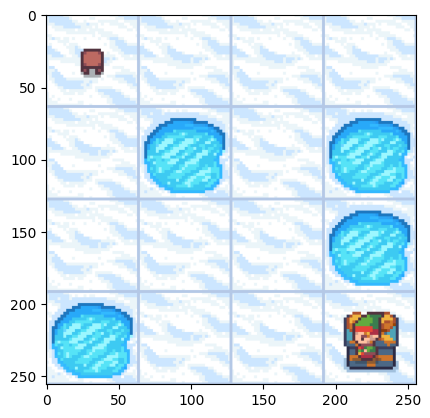

In [ ]:
improved_policy = {}
print(policy)

for state in range(num_states-1):
    # Find the best action for each state based on Q-values
    max_action = max(range(num_actions), key=lambda action: Q[(state, action)])
    improved_policy[state] = max_action
    print(f"State {state}: Action {max_action}")

print(improved_policy)

terminated = False
while not terminated:
  # Select action based on policy
  action = improved_policy[state]
  # Execute the action
  state, reward, terminated, truncated, info = env.step(action)
  render()


  """
Excellent! By observing the agent's movements according to the new improved policy, \
you can understand how much the policy has improved, as the agent reaches the goal \
much faster! Next you'll learn how to optimize the policy even further.
  """

**Applying policy iteration for optimal policy**

Policy iteration is a fundamental technique in RL for finding an optimal policy. It involves two main steps: policy evaluation, where you calculate the state-value function for a given policy, and policy improvement, where you update the policy based on these values. You'll apply these steps iteratively to converge to the optimal policy in the custom FrozenLake/ MyGridWorld environment.

The render_policy() function will be used to show the steps taken by an agent according to a policy.

The **compute_state_value(state, policy)** and **compute_q_value(state, action, policy)** have been preloaded for you.

In [ ]:
policy = {0: 2, 1: 2, 2: 1, 3: 0, 4: 1, 5: 2, 6: 1, 7: 0, 8: 2, 9: 2, 10: 1, 14: 2}
policy

{0: 2, 1: 2, 2: 1, 3: 0, 4: 1, 5: 2, 6: 1, 7: 0, 8: 2, 9: 2, 10: 1, 14: 2}

In [ ]:
def compute_state_value(state, visited=None, policy=policy):
    if visited is None:
        visited = set()

    if policy is None:
        raise ValueError("Policy must be provided")

    if state == terminal_state or state in visited:
        return 0

    visited.add(state)  # Ensure visited is a set before adding

    if state not in policy:
        return 0

    action = policy[state]
    _, next_state, reward, _ = env.unwrapped.P[state][action][0]

    return reward + gamma * compute_state_value(next_state, visited, policy)

# Get number of states from environment
num_states = env.observation_space.n

terminal_state = 15  # Goal state for FrozenLake
gamma = 1  # Discount factor

# Example policy (ensure policy is defined before calling compute_state_value)
policy = {state: 0 for state in range(num_states)}  # Dummy policy mapping each state to action 0

# Compute values for all states
state_values = {state: compute_state_value(state, policy=policy) for state in range(num_states)}
print(state_values)


{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0, 6: 0.0, 7: 0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0, 12: 0, 13: 0.0, 14: 0.0, 15: 0}


In [ ]:
# Compute values for all states
state_values = {state: compute_state_value(state, policy=policy) for state in range(num_states)}
print(state_values)


def policy_evaluation():
  return {state: compute_state_value(state, policy=policy) for state in range(num_states)}


policy_evaluation()

{0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0, 6: 0.0, 7: 0, 8: 0.0, 9: 0.0, 10: 0.0, 11: 0, 12: 0, 13: 0.0, 14: 0.0, 15: 0}


{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0,
 6: 0.0,
 7: 0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0,
 12: 0,
 13: 0.0,
 14: 0.0,
 15: 0}

In [ ]:
# Complete the policy evaluation function
def policy_evaluation(policy):
    V = {state: compute_state_value(state, policy= policy) for state in range(num_states)}
    return V

policy_evaluation(policy)

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.0,
 5: 0,
 6: 0.0,
 7: 0,
 8: 0.0,
 9: 0.0,
 10: 0.0,
 11: 0,
 12: 0,
 13: 0.0,
 14: 0.0,
 15: 0}

In [ ]:
# Complete the function to compute the action-value for a state-action pair
#def compute_q_value(state, action, policy):
 #   if state == terminal_state:
  #      return None
   # probability, next_state, reward, done = env.unwrapped.P[state][action][0]
    #return reward + gamma * policy[next_state]

In [ ]:
#def policy_improvement(policy):
 #   improved_policy = {s: 0 for s in range(num_states-1)}

	# Compute the Q-value for each state-action pair
  #  Q = {(state, action): compute_q_value(state, action, policy) for state in range(num_states) for action in range(num_actions)}

    # Compute the new policy based on the Q-values
   # for state in range(num_states-1):
    #    max_action = max(range(num_actions), key = lambda action: Q[(state, action)])
     #   improved_policy[state] = max_action

   # return improved_policy

#policy_improvement(policy)

In [ ]:
# import warnings, so we can ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import gym

# Initialize the FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)  # Deterministic environment

# Define constants
gamma = 1  # Discount factor
num_states = env.observation_space.n
num_actions = env.action_space.n
terminal_state = num_states - 1  # Assuming last state is terminal

# Compute the Q-value for a given state-action pair
def compute_q_value(state, action, policy, state_values):
    if state == terminal_state:
        return 0  # Q-value for terminal state is 0

    probability, next_state, reward, done = env.unwrapped.P[state][action][0]

    # Approximate Q-value using reward and next state value
    return reward + gamma * state_values.get(next_state, 0)

# Policy Improvement function
def policy_improvement(policy):
    # Estimate state values based on the current policy
    state_values = {s: 0 for s in range(num_states)}

    # Compute Q-values for all state-action pairs
    Q = {}
    for state in range(num_states):
        for action in range(num_actions):
            Q[(state, action)] = compute_q_value(state, action, policy, state_values)

    # Compute the improved policy by choosing the best action per state
    improved_policy = {}
    for state in range(num_states):
        best_action = max(range(num_actions), key=lambda action: Q[(state, action)])
        improved_policy[state] = best_action

    return improved_policy

# Example initial policy (random actions)
policy = {state: env.action_space.sample() for state in range(num_states)}

# Run policy improvement
new_policy = policy_improvement(policy)
print("Improved Policy:", new_policy)


Improved Policy: {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 2, 15: 0}


In [ ]:
# Complete the policy iteration function
def policy_iteration():
    policy = {0:2, 1:2, 2:1, 3:1, 4:0, 5:0, 6:2, 7:2}
    while True:
        V = policy_evaluation(policy)
        improved_policy = policy_improvement(policy)
        if improved_policy == policy:
            break
        policy = improved_policy

    return policy, V

policy, V = policy_iteration()
#render_policy(policy)

In [ ]:


def get_max_action_and_V(state, V):
  Q_values = [compute_q_value(state, action, policy, V) for action in range(num_actions)]
  max_action = max(range(num_actions), key=lambda action: Q_values[action])

  max_q_value = Q_values[max_action]

  return max_action, max_q_value

**Implementing value iteration**

Value iteration is a key method in RL for finding the optimal policy. It iteratively improves the value function for each state until it converges, resulting in the discovery of the optimal policy. You'll start with an initialized value function V and policy, both preloaded for you. Then, you'll update them in a loop until the value function converges and see the policy in action.

The get_max_action_and_value(state, V) function has been pre-loaded for you.

In [ ]:
threshold = 0.001
while True:
  new_V = {state: 0 for state in range(num_states)}
  for state in range(num_states-1):
    # Get action with maximum Q-value and its value
    max_action, max_q_value = get_max_action_and_value(state, V)
    # Update the value function and policy
    new_V[state] = max_q_value
    policy[state] = max_action
  # Test if change in state values is negligeable
  if all(abs(new_V[state] - V[state]) < threshold for state in V):
    break
  V = new_V
render_policy(policy)

"Wonderful! Look at the optimal policy obtained through value iteration. It's \
the same as the one obtained with policy iteration, which means both converge to the same solution, but value iteration with fewer steps."

# **3. Model-Free Learning**


Embark on a journey through the dynamic realm of Model-Free Learning in RL. Get introduced to to the foundational Monte Carlo methods, and apply first-visit and every-visit Monte Carlo prediction algorithms. Transition into the world of Temporal Difference Learning, exploring the SARSA algorithm. Finally, dive into the depths of Q-Learning, and analyze its convergence in challenging environments.

**Episode generation for Monte Carlo methods**

Monte Carlo methods require episodes to be generated in order to derive the value function. Therefore, you'll now implement a function that generates episodes by selecting actions randomly until an episode terminates. In later exercises, you will call this function to apply Monte Carlo methods on the custom environment env pre-loaded for you.

The render() function is pre-loaded for you.

In [ ]:
import numpy as np

def generate_episode(env = env):
    """
    Generates an episode by selecting random actions.

    Args:
        env: The environment to interact with.

    Returns:
        episode: A list of (state, action, reward) tuples.
    """
    episode = []
    state = env.reset()  # Initialize the environment
    done = False

    while not done:
        action = env.action_space.sample()  # Choose a random action
        next_state, reward, done, _ = env.step(action)  # Take a step
        episode.append((state, action, reward))  # Store (s, a, r)
        state = next_state  # Move to next state

    return episode


In [ ]:

# Initialize the FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)  # Deterministic environment


env.reset()  # Reset environment first
env.render()  # Now safe to visualize

episode = generate_episode(env)
print(episode)  # Check the generated episode

[(0, 0, 0.0), (0, 3, 0.0), (0, 3, 0.0), (0, 3, 0.0), (0, 2, 0.0), (1, 3, 0.0), (1, 3, 0.0), (1, 3, 0.0), (1, 0, 0.0), (0, 0, 0.0), (0, 2, 0.0), (1, 1, 0.0)]


In [ ]:

# Initialize the FrozenLake environment
env = gym.make("FrozenLake-v1", is_slippery=False)  # Deterministic environment


env.reset()  # Reset environment first


#def generate_episode():
 #   episode = []
  #  # Reset the environment
   # state, info = env.reset()
    #terminated = False
    #while not terminated:
      # Select a random action
     # action = env.action_space.sample()
      #next_state, reward, terminated, truncated, info = env.step(action)
      #render()
      # Update episode data
      #episode.append((state, action, reward))
      #state = next_state
    #return episode
#print(generate_episode())



"Well done! You've implemented an episode generation function that's essential \
for applying Monte Carlo methods in RL. You can compare the steps taken in the printed episode data with the rendered progression of the agent."

"Well done! You've implemented an episode generation function that's essential for applying Monte Carlo methods in RL. You can compare the steps taken in the printed episode data with the rendered progression of the agent."

**Implementing first-visit Monte Carlo**

The goal of Monte Carlo algorithms is to estimate the Q-table in order to derive an optimal policy. In this exercise, you will implement the First-Visit Monte Carlo method to estimate the action-value function Q, and then compute the optimal policy to solve the custom environment you've seen in the previous exercise. Whenever computing the return, assume a discount factor of 1.

The numpy arrays Q, returns_sum, and returns_count, storing the Q-values, the cumulative sum of rewards, and the count of visits for each state-action pair, respectively, have been initialized and pre-loaded for you.

In [ ]:
# Initialize environment
env = gym.make("FrozenLake-v1", is_slippery=False)  # Deterministic version

# Initialize parameters
num_states = env.observation_space.n  # Number of states
num_actions = env.action_space.n  # Number of actions

# Q-table and tracking variables
Q = np.zeros((num_states, num_actions))  # Action-value function
returns_sum = np.zeros((num_states, num_actions))  # Sum of returns
returns_count = np.zeros((num_states, num_actions))  # Count of visits



# print them
print(Q)
print(returns_sum)
print(returns_count)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
import numpy as np
import gym

# Define action symbols for better visualization
ACTION_SYMBOLS = {
    0: '←',  # LEFT
    1: '↓',  # DOWN
    2: '→',  # RIGHT
    3: '↑'   # UP
}

def get_policy():
    """
    Extracts the best action for each state based on the Q-table.

    Returns:
        policy: A 1D NumPy array of best actions for each state.
    """
    return np.argmax(Q, axis=1)

def render_policy(policy, env_shape=(4, 4)):
    """
    Renders the learned policy in a grid format.

    Args:
        policy: A NumPy array representing the best action for each state.
        env_shape: The shape of the environment (default is 4x4 for FrozenLake).

    Prints:
        A visual representation of the policy.
    """
    policy_grid = np.array([ACTION_SYMBOLS[action] for action in policy])
    policy_grid = policy_grid.reshape(env_shape)

    print("\nOptimal Policy:")
    for row in policy_grid:
        print(" ".join(row))

# Example: Run and render policy after learning
policy = get_policy()
render_policy(policy)



Optimal Policy:
↓ ← ← ←
← ← ← ←
→ ↓ ← ←
← ↓ → ←


In [ ]:
for i in range(100):
  episode = generate_episode(env)
  visited_states = set()
  for j, (state, action, reward) in enumerate(episode):
    # Define the first-visit condition
    if (state, action) not in visited_states:
      # Update the returns, their counts and the visited states
      returns_sum[state, action] += sum([x[2] for x in episode[j:]])
      returns_count[state, action] += 1
      visited_states.add((state, action))

nonzero_counts = returns_count != 0

Q[nonzero_counts] = returns_sum[nonzero_counts] / returns_count[nonzero_counts]
render_policy(get_policy())


"Congratulations! You've successfully implemented the First-Visit Monte Carlo method. By accurately estimating the expected returns of state-action pairs, you're now equipped with a key tool for developing intelligent agents capable of learning optimal policies."




Optimal Policy:
↓ ← ← ←
← ← ← ←
← ↓ ← ←
← ↓ → ←


"Congratulations! You've successfully implemented the First-Visit Monte Carlo method. By accurately estimating the expected returns of state-action pairs, you're now equipped with a key tool for developing intelligent agents capable of learning optimal policies."

**Implementing every-visit Monte Carlo**

The Every-Visit Monte Carlo method differs from the First-Visit variant by updating values every time a state-action pair appears, rather than only on first encounters. While this approach provides a comprehensive evaluation of the policy by utilizing all the available information from the episodes, it may also introduce more variance in the value estimates because it includes all samples, regardless of when they occur in the episode. Your task is to complete the implementation of the every_visit_mc() function, which estimates the action-value function Q over num_episodes episodes.

The dictionaries returns_sum, and returns_count, with state-action pairs as keys have been initialized and pre-loaded for you along with the generate_episode() function.

In [ ]:
Q = np.zeros((num_states, num_actions))
for i in range(100):
  # Generate an episode
  episode = generate_episode()
  # Update the returns and their counts
  for j, (state, action, reward) in enumerate(episode):
    returns_sum[(state,  action)] += sum([x[2] for x in episode[j:]])
    returns_count[(state,  action)] += 1

# Update the Q-values for visited state-action pairs
nonzero_counts = returns_count !=0
Q[nonzero_counts] = returns_sum[nonzero_counts] / returns_count[nonzero_counts]

render_policy(get_policy())

"Great job! You've successfully implemented the every-visit Monte Carlo method for \
estimating action-value functions in RL. As observed, it produced the same policy as \
the first-visit method. This is likely due to the simplicity of the environment and the training conducted over 100 episodes."


Optimal Policy:
↓ ← ← ←
↓ ← ← ←
← ↓ ← ←
← → → ←


"Great job! You've successfully implemented the every-visit Monte Carlo method for estimating action-value functions in RL. As observed, it produced the same policy as the first-visit method. This is likely due to the simplicity of the environment and the training conducted over 100 episodes."

**Implementing the SARSA update rule**

SARSA is an on-policy algorithm in RL that updates the action-value function based on the action taken and the action selected in the next state. This method helps to learn the value of not just the current state-action pair but also the subsequent one, providing a way to learn policies that consider future actions. The SARSA update rule is below, and your task is to implement a function that updates a Q-table based on this rule.

The NumPy library has been imported to you as np.


**Instructions**

- Retrieve the current Q-value for the given state-action pair.
- Find the Q-value for the next state-action pair.
- Update the Q-value for the current state-action pair using the SARSA formula.
- Update the Q-table Q, given that an agent takes action 0 in state 0, receives - a reward of 5, moves to state 1, and performs action 1.

In [ ]:
def update_q_table(state, action, reward, next_state, next_action):
  	# Get the old value of the current state-action pair
    old_value = Q[state, action]
    # Get the value of the next state-action pair
    next_value = Q[next_state, next_action]
    # Compute the new value of the current state-action pair
    Q[(state, action)] = (1- alpha) * old_value + alpha * (reward + gamma * next_value)

alpha = 0.1
gamma  = 0.8
Q = np.array([[10,0],[0,20]], dtype='float32')
# Update the Q-table for the ('state1', 'action1') pair
update_q_table(0, 0, 5, 1, 1)
print(Q)
print(Q)


"Bravo! You've successfully implemented the SARSA update rule for Q-learning. \
By applying this method, you are able to iteratively improve the Q-values based \
on the agent's experiences, effectively learning an optimal policy over time."

[[11.1  0. ]
 [ 0.  20. ]]
[[11.1  0. ]
 [ 0.  20. ]]


"Bravo! You've successfully implemented the SARSA update rule for Q-learning. By applying this method, you are able to iteratively improve the Q-values based on the agent's experiences, effectively learning an optimal policy over time."

**Solving 8x8 Frozen Lake with SARSA**

In this exercise, you will apply the SARSA algorithm, incorporating the update_q_table() function you previously implemented, to learn an optimal policy for the 8x8 Frozen Lake environment. This environment is identical to the classic 4x4 one, with the only difference of being bigger. You will use the SARSA algorithm to iteratively improve the agent's policy based on the rewards received from the environment.

A Q-table Q has been initialized and pre-loaded for you, along with the update_q_table() function from the previous exercise.

unknown.svg

In [ ]:
import numpy as np

# Define symbols for actions
ACTION_SYMBOLS = {0: '←', 1: '↓', 2: '→', 3: '↑'}  # Left, Down, Right, Up

def get_policy():
    """
    Extracts the best action for each state based on the Q-table.

    Returns:
        policy: A 1D NumPy array of best actions for each state.
    """
    return np.argmax(Q, axis=1)  # Select action with highest Q-value per state

def render_policy(policy, env_shape=(8, 8)):
    """
    Renders the learned policy in a grid format.

    Args:
        policy: A NumPy array representing the best action for each state.
        env_shape: The shape of the environment (default is 8x8 for FrozenLake).

    Prints:
        A visual representation of the policy.
    """
    policy_grid = np.array([ACTION_SYMBOLS[action] for action in policy])  # Map actions to symbols
    policy_grid = policy_grid.reshape(env_shape)  # Reshape to match environment

    print("\nOptimal Policy:")
    for row in policy_grid:
        print(" ".join(row))

# Example: Run and render policy after learning
policy = get_policy()
render_policy(policy)



Optimal Policy:
← ← ← ← ← ← ← ←
← ← ← ← ← ← ← ←
← ← ← ← ← ← ← ←
← ← ← ← ← ← ← ←
← ← ← ← ← ← ← ←
← ← ← ← ← ← ← ←
← ← ← ← ← ← ← ↓
← ← ← ← ← ← ← ←


In [ ]:
# Initialize Q-table for 64 states and 4 actions
Q = np.zeros((64, 4), dtype='float32')

def update_q_table(state, action, reward, next_state, next_action):
    """
    Update Q-table using the SARSA update rule.
    """
    old_value = Q[state, action]
    next_value = Q[next_state, next_action] if next_state < 64 else 0  # Avoid out-of-bounds error
    Q[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_value)

# Initialize 8x8 FrozenLake environment

In [ ]:
num_episodes = 1000
env = gym.make("FrozenLake8x8-v1", is_slippery=False)

for episode in range(num_episodes):
    state = env.reset()
    action = env.action_space.sample()
    terminated = False
    while not terminated:
      	# Execute the action
        next_state, reward, terminated, truncated = env.step(action)
        # Choose the next action randomly
        next_action = env.action_space.sample()
        # Update the Q-table
        update_q_table(state, action, reward, next_state, next_action)
        state, action = next_state, next_action


render_policy(get_policy())

"Fantastic work! You've successfully integrated the SARSA algorithm to solve the 8x8 Frozen Lake challenge. This exercise not only reinforced your understanding of the SARSA update mechanism but also demonstrated how to apply it in a practical, complex environment."






Optimal Policy:
→ → → → → → → ↓
↑ → → → → → → ↓
↑ ↑ ↑ ← ↑ → → ↓
↑ ↑ ↑ ← ↑ ← → ↓
↑ ↑ ↑ ← ← ← ↑ ↓
↑ ← ← ← ← ← ← ↓
↑ ← ← ← ← ← ← ↓
↑ ← ← ← ← ← → ←


"Fantastic work! You've successfully integrated the SARSA algorithm to solve the 8x8 Frozen Lake challenge. This exercise not only reinforced your understanding of the SARSA update mechanism but also demonstrated how to apply it in a practical, complex environment."

**Implementing Q-learning update rule**

Q-learning is an off-policy algorithm in reinforcement learning (RL) that seeks to find the best action to take given the current state. Unlike SARSA, which considers the actual next action taken, Q-learning updates its Q-values using the maximum future reward irrespective of the action taken. This distinction allows Q-learning to learn the optimal policy while following an exploratory or even a random policy. Here's the task to implement a function that updates a Q-table based on the Q-learning rule. The Q-learning update rule is below, and your task is to implement a function that updates a Q-table based on this rule.

The NumPy library has been imported to you as np.


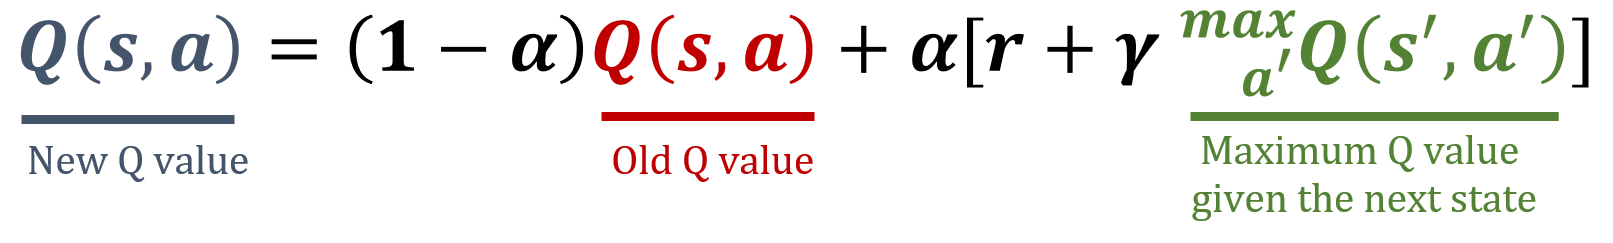

In [ ]:
actions = ['action1', 'action2']
def update_q_table(state, action, reward, next_state):
  	# Get the old value of the current state-action pair
    old_value = Q[state, action]
    # Determine the maximum Q-value for the next state
    next_max = max(Q[next_state])
    # Compute the new value of the current state-action pair
    Q[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)

alpha = 0.1
gamma = 0.95
Q = np.array([[10, 8], [20, 15]], dtype='float32')
# Update the Q-table
update_q_table(0, 0, 5, 1)
print(Q)

"Bravo! You've successfully implemented the Q-learning update rule. This method is \
crucial for learning optimal policies in RL, as it enables the agent to iteratively \
improve its strategy by seeking the maximum reward."

[[11.4  8. ]
 [20.  15. ]]


"Bravo! You've successfully implemented the Q-learning update rule. This method is crucial for learning optimal policies in RL, as it enables the agent to iteratively improve its strategy by seeking the maximum reward."

**Solving 8x8 Frozen Lake with Q-learning**

In this exercise, you'll apply the Q-learning algorithm to learn an optimal policy for navigating through the 8x8 Frozen Lake environment, this time with the "slippery" condition enabled. The challenge introduces stochastic transitions, making the agent's movement unpredictable and thus more closely simulating real-world scenarios.

A Q-table Q has been initialized and pre-loaded for you, along with the update_q_table() function from the previous exercise and an empty list rewards_per_episode that will contain the total reward accumulated through each episode.

**Instuctions**

- For each episode, execute the selected action and observe the reward and next state.
- Update the Q-table.
- Append the total_reward to the rewards_per_episode list.

In [ ]:
def update_q_table(state, action, reward, next_state):
  	# Get the old value of the current state-action pair
    old_value = Q[state, action]
    # Determine the maximum Q-value for the next state
    next_max = max(Q[next_state])
    # Compute the new value of the current state-action pair
    Q[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)

In [ ]:
rewards_per_episode = []

for episode in range(1000):
    state = env.reset()
    total_reward = 0
    terminated = False
    while not terminated:
        action = env.action_space.sample()
        # Execute the action
        next_state, reward, terminated, truncated = env.step(action)
        # Update the Q-table
        update_q_table(state, action, reward, next_state)
        #state = next_state
        state = next_state
        total_reward += reward
    # Append the total reward to the rewards list
    rewards_per_episode.append(total_reward)
print("Average reward per random episode: ", np.mean(rewards_per_episode))

"Outstanding! You've successfully applied the Q-learning algorithm to navigate the slippery 8x8 Frozen Lake. The next step would be to evaluate it."

Average reward per random episode:  0.002


"Outstanding! You've successfully applied the Q-learning algorithm to navigate the slippery 8x8 Frozen Lake. The next step would be to evaluate it."

**Evaluating policy on a slippery Frozen Lake**

In a slippery Frozen Lake environment, merely deducing the policy from a learned Q-table isn't sufficient to gauge its effectiveness. To accurately assess the suitability of a learned policy, you must play multiple episodes, observing the average reward achieved. This exercise compares the effectiveness of the learned policy against a baseline established by following a random policy during training. Your task is to execute the learned policy over several episodes and analyze its performance based on the average rewards collected, contrasting it with the average rewards collected during the random policy phase.

The Q-table Q, num_states, num_actions, and avg_reward_per_random_episode have been pre-loaded for you. The NumPy library has been imported as np.

In [ ]:
import numpy as np
import gym

# Define the environment (for example, using FrozenLake)
env = gym.make("FrozenLake-v1", is_slippery=False)

# Q-table initialization (for example, 4x4 environment with 4 actions)
Q = np.zeros((env.observation_space.n, env.action_space.n))

# Hyperparameters
alpha = 0.1  # Learning rate
gamma = 0.95  # Discount factor

reward_per_learned_episode = []  # To store rewards from learned episodes
reward_per_random_episode = []  # To store rewards from random episodes (for comparison)

# Training loop
for episode in range(10000):
    state = env.reset()  # Initialize state
    terminated = False
    episode_reward = 0

    # Episode loop (timesteps within each episode)
    while not terminated:
        # Select the best action based on the learned Q-table (greedy policy)
        action = np.argmax(Q[state])  # Greedy action selection: choose the action with the highest Q-value for the state

        # Take the action and get the next state and reward
        new_state, reward, terminated, truncated  = env.step(action)

        # Update Q-table using the SARSA or Q-learning update rule (optional, based on your algorithm)
        # (Here we're not performing updates for simplicity)

        # Transition to the new state
        state = new_state
        episode_reward += reward  # Accumulate reward for the episode

    # Store the reward for this episode
    reward_per_learned_episode.append(episode_reward)

# Compute and print the average reward per learned episode
avg_reward_per_learned_episode = np.mean(reward_per_learned_episode)
print("Average reward per learned episode: ", avg_reward_per_learned_episode)

# If you want to compare with random actions
for episode in range(1000):  # Random policy for comparison
    state  = env.reset()
    terminated = False
    episode_reward = 0

    while not terminated:
        # Select a random action
        action = env.action_space.sample()  # Random action

        # Take the random action and get the next state and reward
        new_state, reward, terminated, truncated  = env.step(action)

        state = new_state
        episode_reward += reward

    reward_per_random_episode.append(episode_reward)

# Compute and print the average reward for random episodes
avg_reward_per_random_episode = np.mean(reward_per_random_episode)
print("Average reward per random episode: ", avg_reward_per_random_episode)



"Excellent work! You've successfully evaluated the learned policy in the slippery \
8x8 Frozen Lake environment. By comparing the average reward from the learned policy \
to that achieved with a random policy, you've quantitatively assessed the improvement brought by applying Q-learning."

Average reward per learned episode:  0.0
Average reward per random episode:  0.016


# **4. Advanced Strategies in Model Free RL**

Dive into advanced strategies in Model-Free RL, focusing on enhancing decision-making algorithms. Learn about Expected SARSA for more accurate policy updates and Double Q-learning to mitigate overestimation bias. Explore the Exploration-Exploitation Tradeoff, mastering epsilon-greedy and epsilon-decay strategies for optimal action selection. Tackle the Multi-Armed Bandit Problem, applying strategies to solve decision-making challenges under uncertainty.

**Your recent learnings**

When you left 8 days ago, you worked on Model-Free Learning, chapter 3 of the course Reinforcement Learning with Gymnasium in Python. Here is what you covered in your last lesson:

You learned about Q-learning, a model-free reinforcement learning technique used to find the optimal action-selection policy. Unlike SARSA, which updates its Q-values based on the action actually taken, Q-learning updates its Q-values using the maximum possible future reward, making it an off-policy algorithm.

Key points covered:

- Q-learning Basics: Q-learning helps an agent learn the optimal Q-table by interacting with an environment and updating the Q-values based on the maximum future reward.
- Q-learning Update Rule: The Q-value for a state-action pair is updated using the formula: [ Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right] ]
- Implementation: You implemented the Q-learning update rule in Python:




```
def update_q_table(state, action, reward, next_state):
    old_value = Q[state, action]
    next_max = max(Q[next_state])
    Q[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
```

- Application: You applied Q-learning to solve the slippery Frozen Lake environment, comparing the agent's performance using a learned policy versus a random policy.
By the end of the lesson, you saw how Q-learning can effectively learn an optimal policy, even in stochastic environments.

The goal of the next lesson is to learn how to implement Expected SARSA in a new environment to improve an agent's decision-making.
